# 제조 AI 4주차


## STEP 0 

데이터 다운로드 위치
Kaggle: https://www.kaggle.com/datasets/kaustubhdikshit/neu-surface-defect-database

### 프로젝트 구조

```text
Manufacturing_AI_Project/
├── 제조AI_1주차.ipynb
├── 제조AI_4주차.ipynb
│
└── NEU-DET/
    ├── train/
    │   └── images/
    │       ├── crazing/
    │       ├── inclusion/
    │       ├── patches/
    │       ├── pitted_surface/
    │       ├── rolled-in_scale/
    │       └── scratches/
    │
    └── validation/
        └── images/

```



In [1]:
import os
import koreanize_matplotlib
# NEU-DET 데이터셋의 기본 경로
BASE_DIR = './NEU-DET'

# 학습 이미지 경로
DATA_DIR = os.path.join(BASE_DIR, 'train', 'images')

print('DATA_DIR =', DATA_DIR)

# 클래스별 이미지 개수 확인
for d in sorted(os.listdir(DATA_DIR)):
    p = os.path.join(DATA_DIR, d)
    
    if os.path.isdir(p):
        print(f'{d}: {len(os.listdir(p))}장')

DATA_DIR = ./NEU-DET/train/images
crazing: 240장
inclusion: 240장
patches: 240장
pitted_surface: 240장
rolled-in_scale: 240장
scratches: 240장


In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models

# TensorFlow에서 사용 가능한 GPU 확인
print('GPU:', tf.config.list_physical_devices('GPU'))

# 이미지 크기와 한 번에 학습할 이미지 수(배치) 설정
IMG, BATCH = 224, 32

# 전체 이미지 중 80%를 학습 데이터로 사용
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR, 
    validation_split=0.2, 
    subset='training', 
    seed=42,
    image_size=(IMG, IMG), 
    batch_size=BATCH)
# 전체 이미지 중 20%를 검증 데이터로 사용
val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR, 
    validation_split=0.2, 
    subset='validation', 
    seed=42,
    image_size=(IMG, IMG), 
    batch_size=BATCH)

class_names = train_ds.class_names
print('클래스 6종:', class_names)      

GPU: []
Found 1440 files belonging to 6 classes.
Using 1152 files for training.
Found 1440 files belonging to 6 classes.
Using 288 files for validation.
클래스 6종: ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']


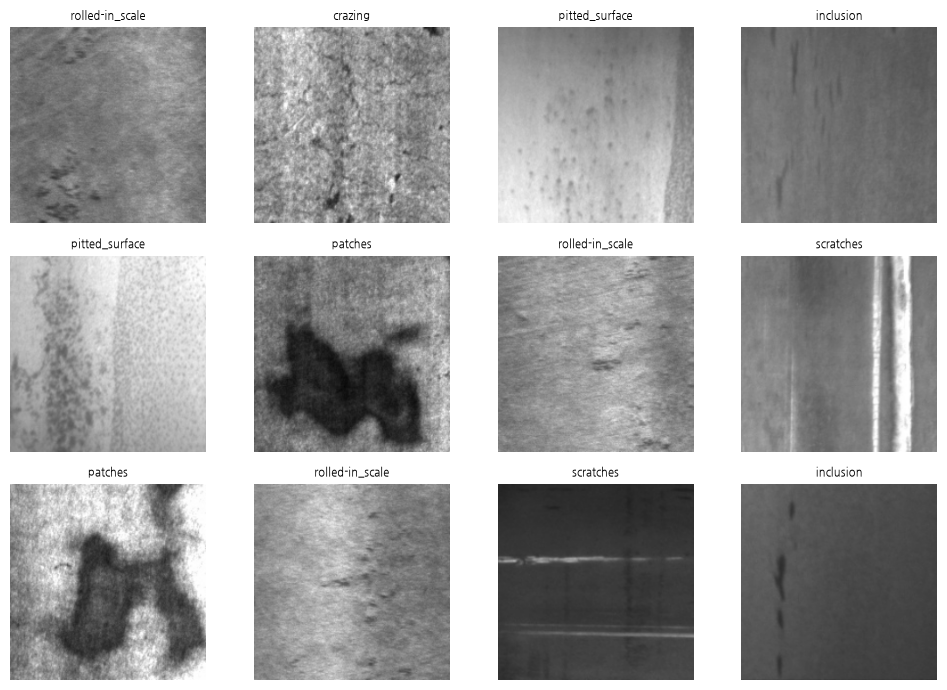

In [3]:
import matplotlib.pyplot as plt

# 3행 × 4열 형태의 이미지 그리드 생성
fig, axes = plt.subplots(3, 4, figsize=(10, 7))

# 학습 데이터에서 첫 번째 배치만 가져오기
for images, labels in train_ds.take(1):

    # 12개의 이미지를 그리드에 출력
    for i, ax in enumerate(axes.flat):
        
        # TensorFlow 이미지를 uint8 형식으로 변환하여 출력
        ax.imshow(images[i].numpy().astype('uint8'))
        
        # 이미지의 실제 클래스 이름을 제목으로 표시
        ax.set_title(class_names[labels[i]], fontsize=8)
        
        # 이미지이므로 x축, y축 숨기기
        ax.axis('off')

# 이미지 간 간격 자동 조정
plt.tight_layout()

# 결과 출력
plt.show()

In [4]:
# 데이터 증강(Data Augmentation) 설정
aug = models.Sequential([
    layers.RandomFlip('horizontal'),    # 이미지를 좌우로 무작위 반전
    layers.RandomRotation(0.05),        # 이미지를 무작위로 약 ±5% 회전
    layers.RandomBrightness(0.1),       # 이미지 밝기를 무작위로 변경
])

# 데이터 로딩 속도를 자동으로 최적화
AUTOTUNE = tf.data.AUTOTUNE

# 모델이 학습하는 동안 다음 데이터를 미리 준비하여 학습 속도 향상
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)

## 전이학습 모델 구조

**Input Image**  
`224 × 224 × 3`

↓  

**Data Augmentation**  
`Flip · Rotation · Brightness`

↓  

**MobileNetV2 Preprocessing**

↓  

### ❄️ MobileNetV2 Backbone
- ImageNet Pre-trained
- **Frozen** : 가중치 업데이트 ❌

↓  

**GlobalAveragePooling2D**

↓  

**Dropout (0.2)**

↓  

### 🔥 Classification Head
- `Dense(6) + Softmax`
- **Trainable** : 가중치 업데이트 ⭕

↓  

**Defect Classification (6 Classes)**

In [5]:
# ImageNet으로 사전 학습된 MobileNetV2 불러오기
# include_top=False : 기존 분류기(마지막 출력층)는 사용하지 않음
base = tf.keras.applications.MobileNetV2(
    input_shape=(IMG, IMG, 3),
    include_top=False,
    weights='imagenet'
)

# 사전 학습된 MobileNetV2의 가중치는 업데이트하지 않음
base.trainable = False


# 입력 이미지 정의
inputs = tf.keras.Input(shape=(IMG, IMG, 3))

# 데이터 증강 적용
x = aug(inputs)

# MobileNetV2에 맞게 이미지 픽셀값 전처리
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)

# 사전 학습된 MobileNetV2를 특징 추출기로 사용
x = base(x, training=False)

# 특징 맵의 각 채널을 하나의 값으로 평균내어 1차원 벡터로 변환
x = layers.GlobalAveragePooling2D()(x)

# 과적합 방지를 위해 20%의 뉴런을 무작위로 비활성화
x = layers.Dropout(0.2)(x)

# NEU-DET의 6개 결함 클래스를 분류하는 새로운 출력층 추가
outputs = layers.Dense(
    len(class_names),
    activation='softmax'
)(x)

# 입력부터 출력까지 연결하여 최종 모델 생성
model = tf.keras.Model(inputs, outputs)

# 모델 학습 방법 설정
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 모델 구조 확인
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │         7,686 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,265,670 (8.64 MB)

 Trainable params: 7,686 (30.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [6]:
# 모델 학습
# train_ds : 학습에 사용하는 데이터
# validation_data : 각 Epoch 종료 후 검증 성능 평가
# epochs=5 : 전체 학습 데이터를 5번 반복하여 학습

history_transferlearning = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

Epoch 1/5


/opt/miniconda3/envs/ManufactoringAI/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


36/36 ━━━━━━━━━━━━━━━━━━━━ 11s 267ms/step - accuracy: 0.7422 - loss: 0.8245 - val_accuracy: 0.9375 - val_loss: 0.2936
Epoch 2/5
36/36 ━━━━━━━━━━━━━━━━━━━━ 8s 220ms/step - accuracy: 0.9731 - loss: 0.1594 - val_accuracy: 0.9792 - val_loss: 0.1431
Epoch 3/5
36/36 ━━━━━━━━━━━━━━━━━━━━ 8s 216ms/step - accuracy: 0.9870 - loss: 0.0934 - val_accuracy: 0.9826 - val_loss: 0.1117
Epoch 4/5
36/36 ━━━━━━━━━━━━━━━━━━━━ 8s 216ms/step - accuracy: 0.9896 - loss: 0.0705 - val_accuracy: 0.9896 - val_loss: 0.0774
Epoch 5/5
36/36 ━━━━━━━━━━━━━━━━━━━━ 8s 215ms/step - accuracy: 0.9905 - loss: 0.0548 - val_accuracy: 0.9931 - val_loss: 0.0611


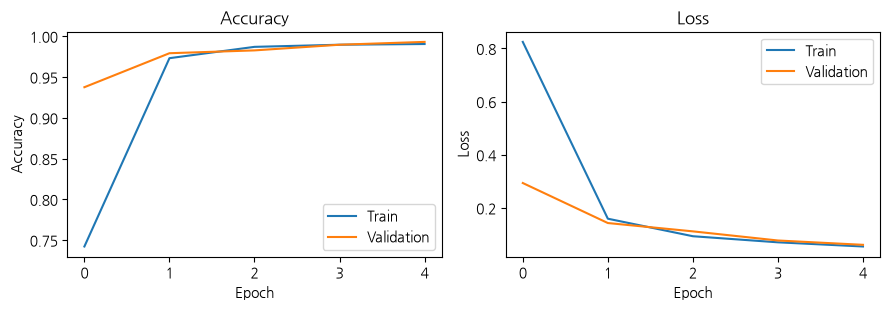

In [7]:
import matplotlib.pyplot as plt

# Accuracy와 Loss 그래프를 나란히 생성
fig, axes = plt.subplots(1, 2, figsize=(9, 3.2))

# Accuracy 변화
axes[0].plot(history_transferlearning.history['accuracy'], label='Train')
axes[0].plot(history_transferlearning.history['val_accuracy'], label='Validation')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# Loss 변화
axes[1].plot(history_transferlearning.history['loss'], label='Train')
axes[1].plot(history_transferlearning.history['val_loss'], label='Validation')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

# 그래프 간격 자동 조정
plt.tight_layout()
plt.show()

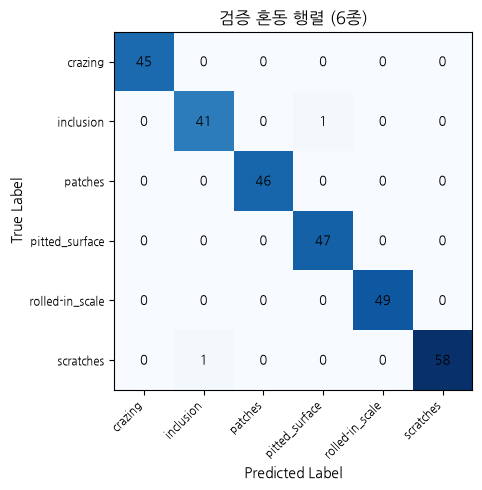

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# 실제 정답과 모델의 예측 결과를 저장할 리스트
y_true = []
y_pred = []

# 검증 데이터 전체에 대해 예측 수행
for images, labels in val_ds:
    
    # 각 이미지가 6개 클래스에 속할 확률 예측
    pred_prob = model.predict(images, verbose=0)
    
    # 실제 클래스 저장
    y_true.extend(labels.numpy().tolist())
    
    # 가장 높은 확률을 가진 클래스를 예측 결과로 저장
    y_pred.extend(pred_prob.argmax(axis=1).tolist())


# 실제 클래스와 예측 클래스를 이용하여 혼동 행렬 생성
cm = confusion_matrix(y_true, y_pred)


# 6 × 6 혼동 행렬 시각화
fig, ax = plt.subplots(figsize=(5.5, 5))

# 혼동 행렬을 이미지 형태로 출력
ax.imshow(cm, cmap='Blues')

# 각 칸에 샘플 개수 표시
for i in range(6):
    for j in range(6):
        ax.text(
            j, i, cm[i, j],
            ha='center',
            va='center',
            fontsize=9
        )

# X축과 Y축에 클래스 이름 표시
ax.set_xticks(range(6))
ax.set_yticks(range(6))

ax.set_xticklabels(
    class_names,
    rotation=45,
    ha='right',
    fontsize=8
)

ax.set_yticklabels(
    class_names,
    fontsize=8
)

# 축과 제목 설정
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.set_title('검증 혼동 행렬 (6종)')

plt.tight_layout()
plt.show()

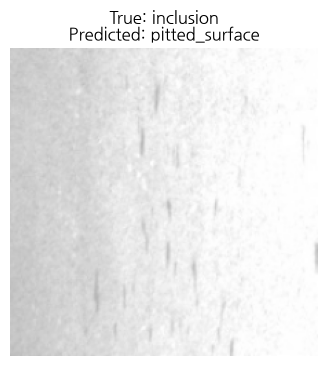

In [ ]:
# 실제 inclusion을 pitted_surface로 잘못 예측한 이미지 찾기
true_class = class_names.index('inclusion')
pred_class = class_names.index('pitted_surface')
for images, labels in val_ds:
    # 모델 예측
    pred_prob = model.predict(images, verbose=0)
    predictions = pred_prob.argmax(axis=1)
    for image, true_label, pred_label in zip(images, labels, predictions):
        # 실제: inclusion / 예측: pitted_surface인 경우
        if true_label.numpy() == true_class and pred_label == pred_class:

            plt.figure(figsize=(4, 4))
            plt.imshow(image.numpy().astype('uint8'))
            plt.title(
                f"True: {class_names[true_label.numpy()]}\n"
                f"Predicted: {class_names[pred_label]}"
            )
            plt.axis('off')
            plt.show()

In [ ]:
# 미세조정(Fine-tuning)

# MobileNetV2의 동결(모델의 가중치 고정)을 해제
base.trainable = True

# 앞쪽 레이어는 계속 동결(모델의 가중치 고정)하고, 마지막 30개 레이어만 학습
for layer in base.layers[:-30]:
    layer.trainable = False

# 학습 가능한 레이어가 변경되었으므로 모델을 다시 컴파일
# 사전 학습된 가중치가 크게 변하지 않도록 작은 학습률 사용
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 마지막 30개 레이어 + 분류층을 함께 미세조정
history_fineturning = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=3
)

# 미세조정 후 마지막 Epoch의 검증 정확도 출력
print(
    '미세조정 후 val accuracy:',
    round(history_fineturning.history['val_accuracy'][-1], 4)
)

Epoch 1/3


/opt/miniconda3/envs/ManufactoringAI/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


36/36 ━━━━━━━━━━━━━━━━━━━━ 12s 268ms/step - accuracy: 0.6927 - loss: 1.0299 - val_accuracy: 0.9861 - val_loss: 0.0651
Epoch 2/3
36/36 ━━━━━━━━━━━━━━━━━━━━ 10s 291ms/step - accuracy: 0.8906 - loss: 0.3560 - val_accuracy: 0.9757 - val_loss: 0.0781
Epoch 3/3
36/36 ━━━━━━━━━━━━━━━━━━━━ 11s 311ms/step - accuracy: 0.9470 - loss: 0.2043 - val_accuracy: 0.9757 - val_loss: 0.0878
미세조정 후 val accuracy: 0.9757


In [11]:
# 미세조정 전/후 검증 정확도 비교

before = history_transferlearning.history['val_accuracy'][-1]
after = history_fineturning.history['val_accuracy'][-1]

print(f'미세조정 전: {before:.4f}')
print(f'미세조정 후: {after:.4f}')
print(f'성능 변화    : {after - before:+.4f}')

미세조정 전: 0.9931
미세조정 후: 0.9757
성능 변화    : -0.0174


# 과제

## 데이터 증강 적용 전/후 성능비교
